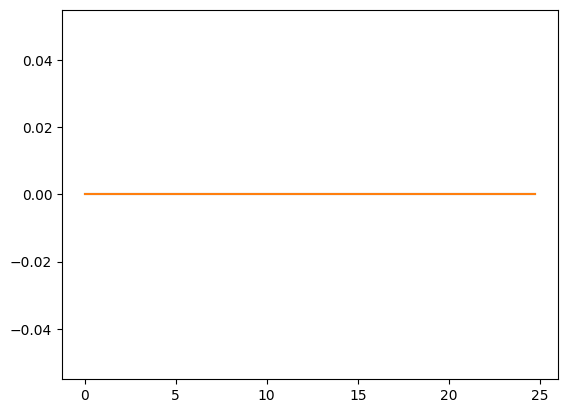

0.0π


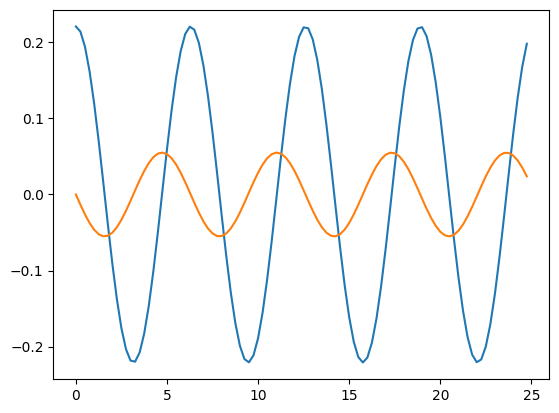

0.0703125π


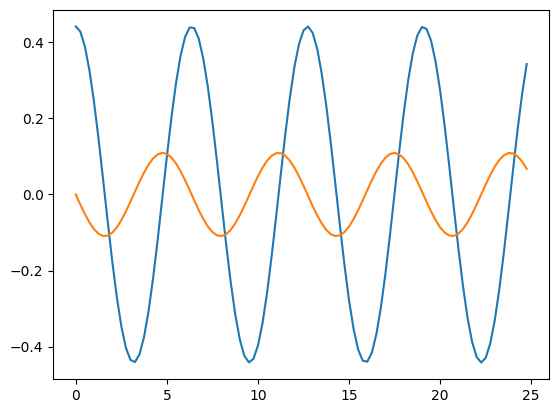

0.140625π


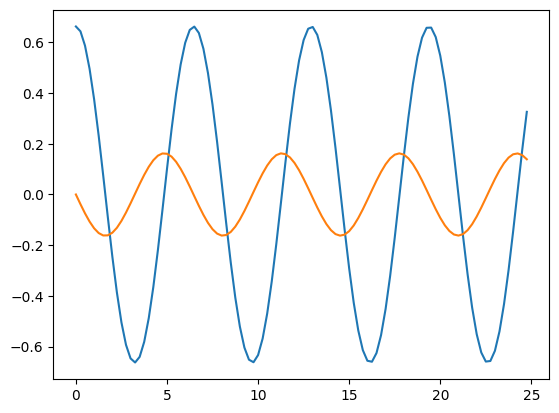

0.2109375π


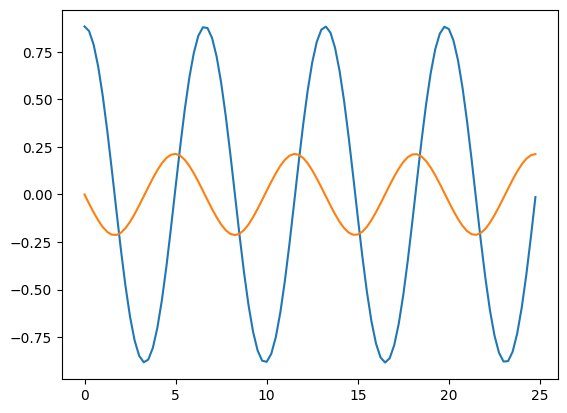

0.28125π


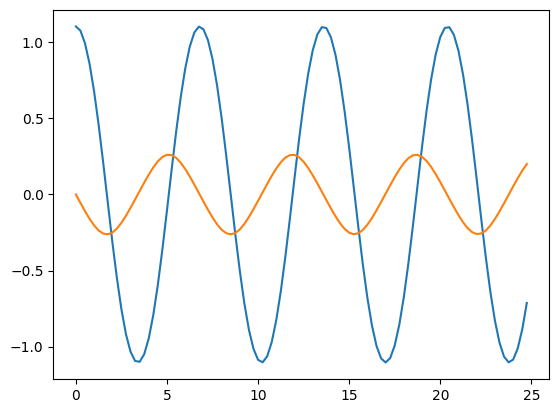

0.3515625π


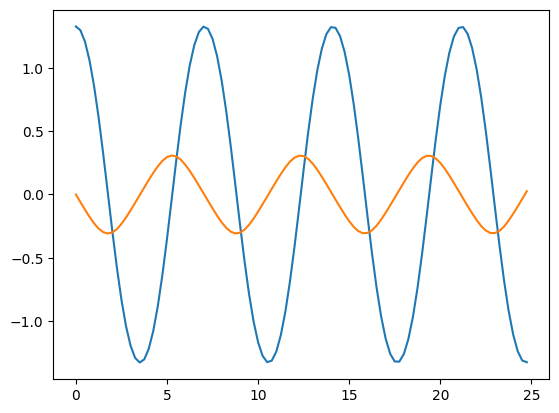

0.421875π


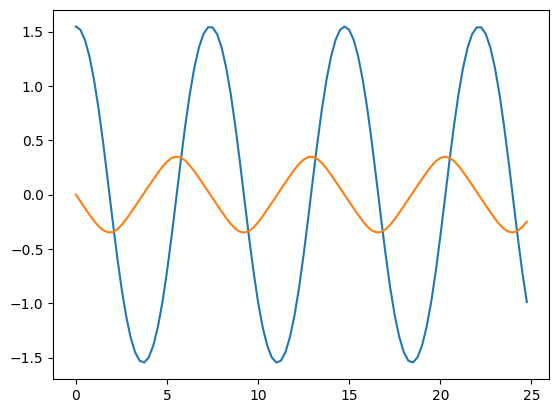

0.4921875π


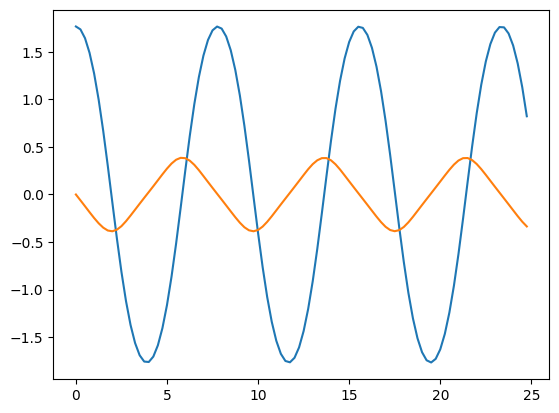

0.5625π


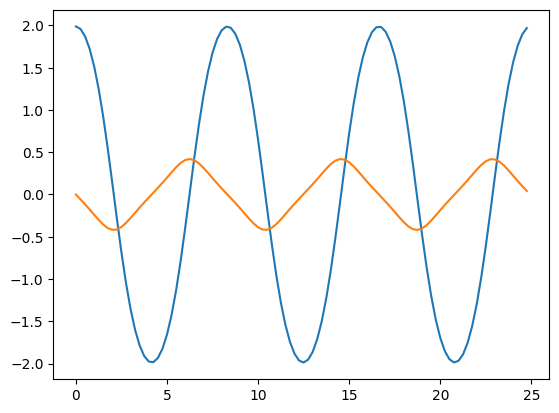

0.6328125π


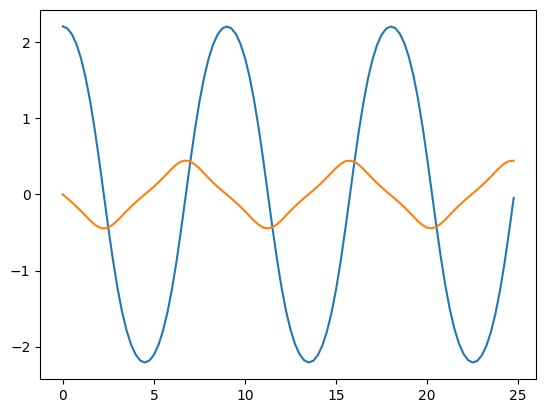

0.703125π


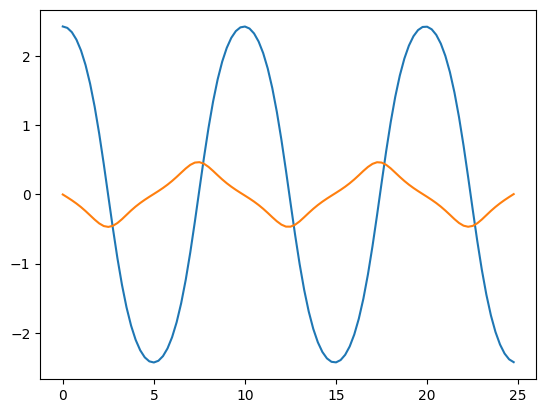

0.7734375π


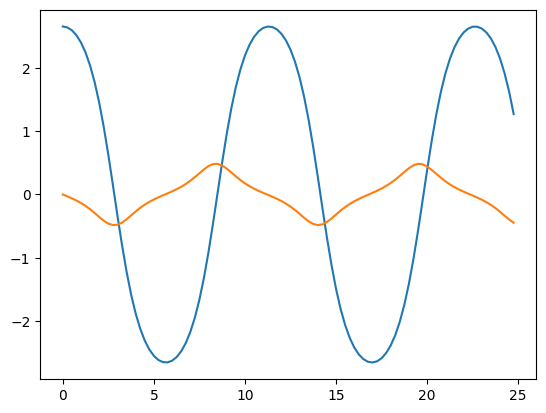

0.84375π


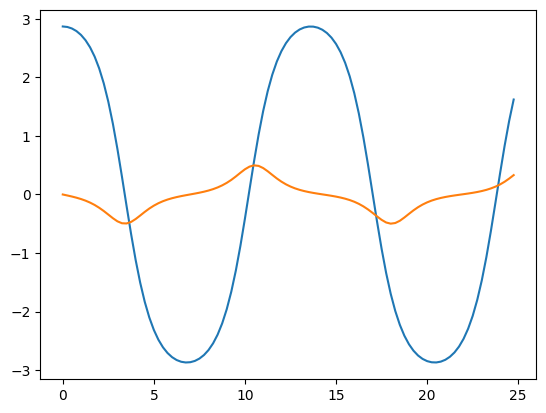

0.9140625π


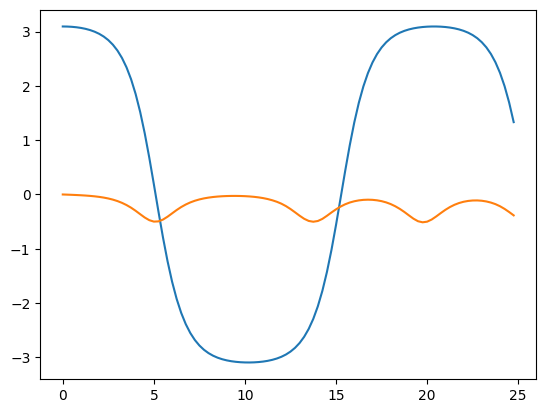

0.984375π


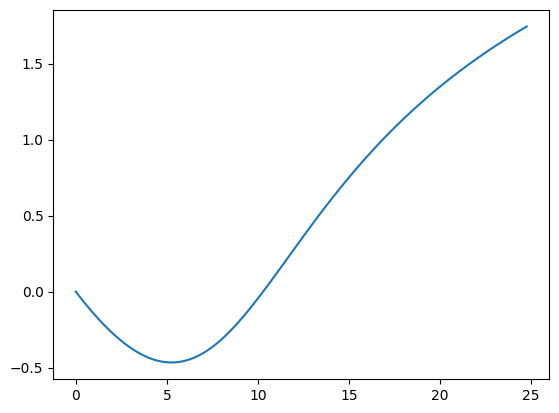

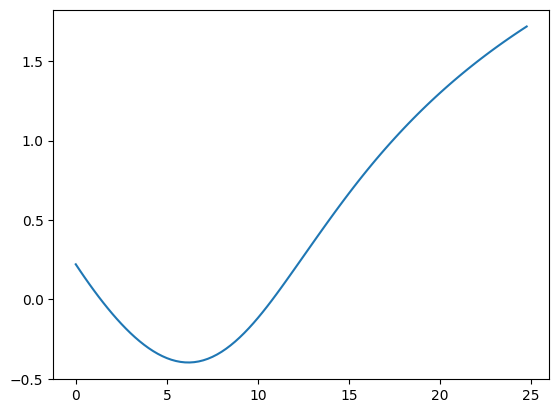

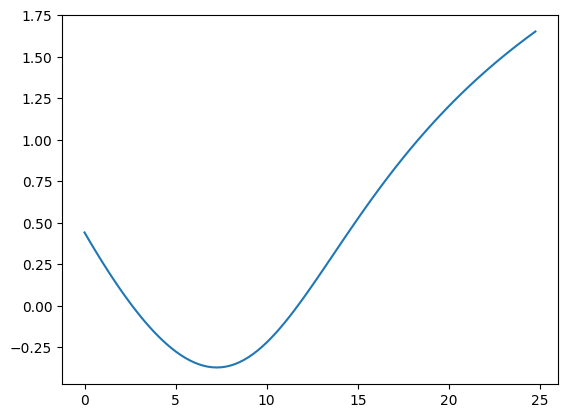

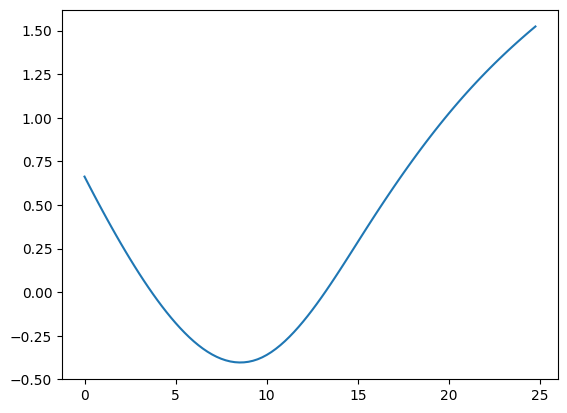

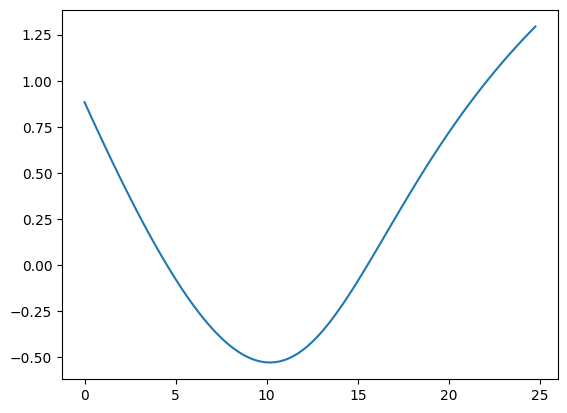

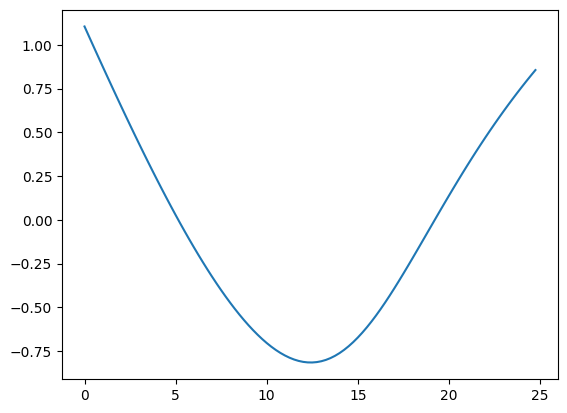

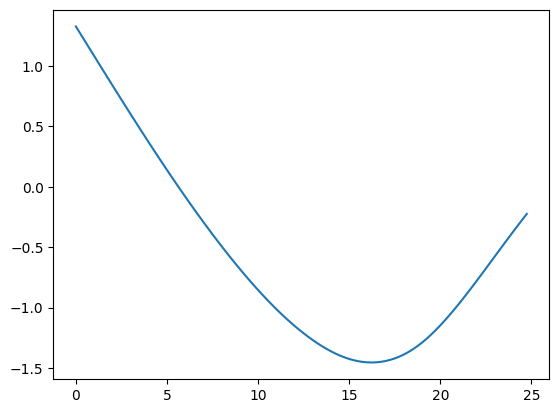

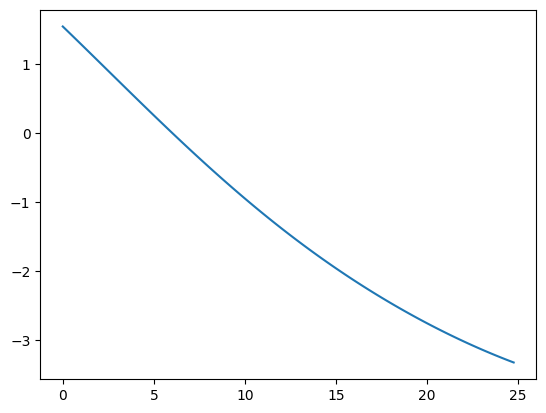

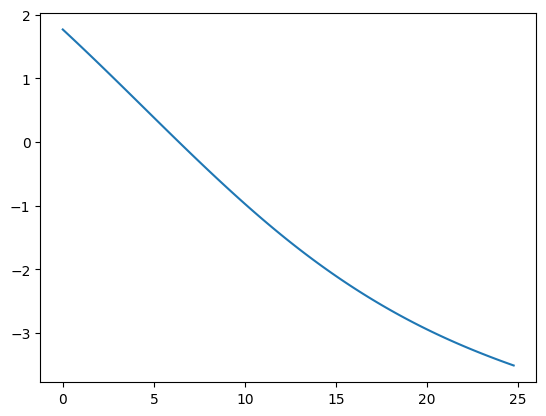

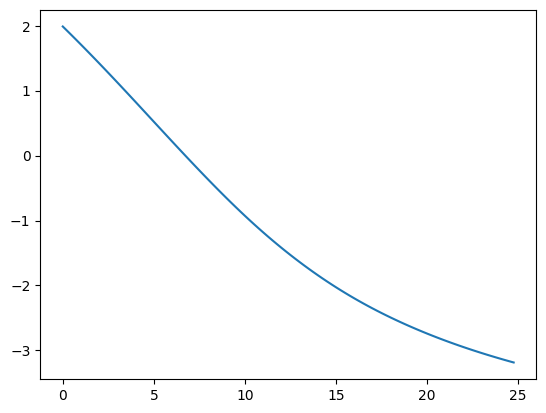

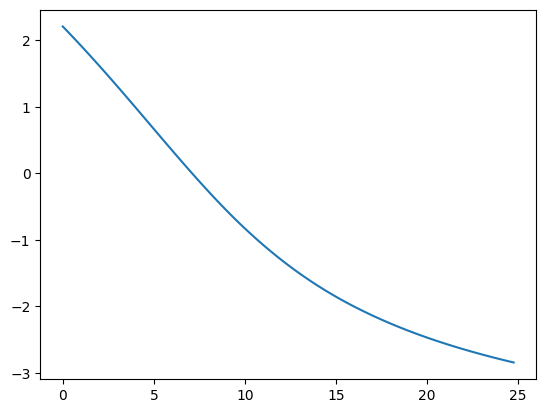

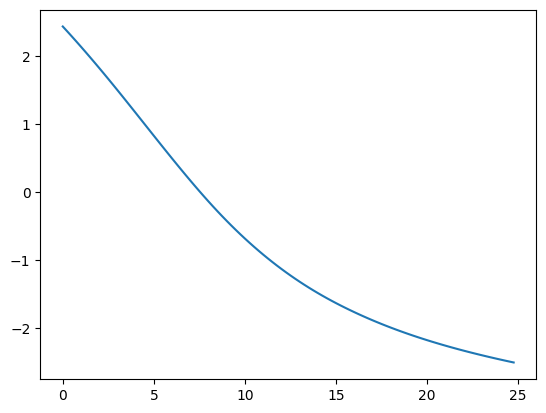

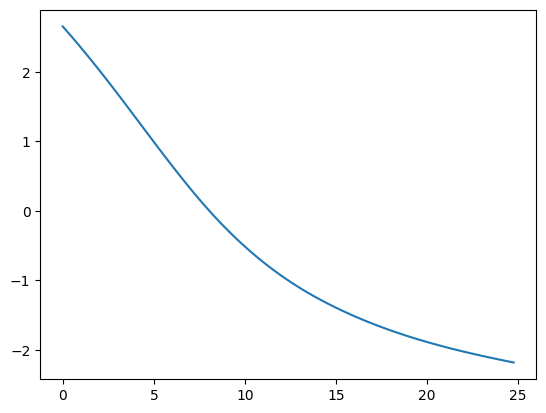

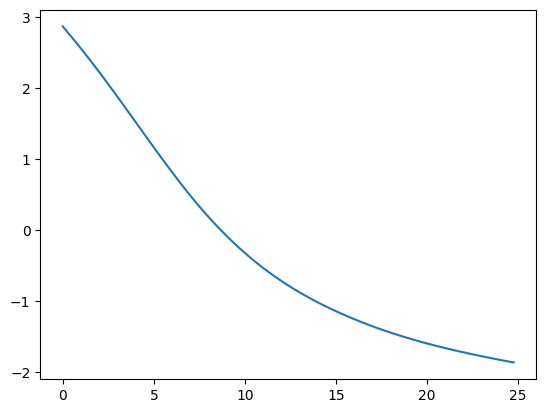

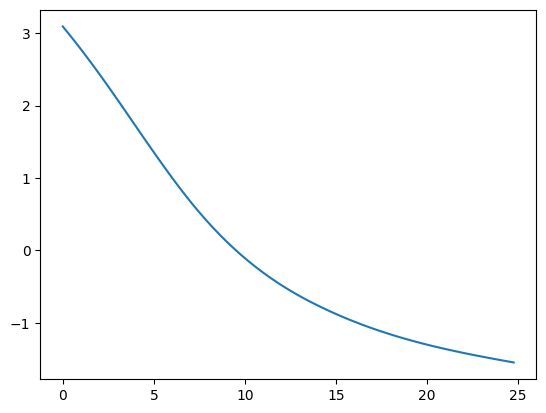

In [ ]:
import scipy.special as sp
import scipy.integrate as integrate
import numpy as np
from matplotlib import pyplot as plt
from scipy.integrate import solve_ivp


#yt=[theta, omega, t]

theta_00=9*np.pi/128 #first initial theta that is not zero.
x_0=[theta_00,0] #inital vector [theta_0, omega_0] for each trajectory.
#omega_0=.1*2.5 
omega_0=.25
# #contant equal to sqrt(g/l) where l is pendulum length.
t=range(100) #time length of tranjectories
n_trajectories=15 #number of trajectories
n_samples=100 #number of points samples from each trajectory
F_theta=np.zeros([np.size(t),1]) #Initalize vector
F_omega=np.zeros([np.size(t),1]) #Initalize vector
tt=omega_0*np.array(range(0,np.size(t))) #Make time range into numpy array

def fx(t,x,omega_0): #define integrator for pendulum ODE to find omega
    return np.array([x[1],-omega_0**2*np.sin(x[0])])

Gmatrix=[]
for i in range(0,n_trajectories):
    theta_0=i*theta_00 #intial theta for each trajectory
    m=np.sin(theta_0/2)**2 #contant for each trajectory
    K=integrate.quad(lambda z:((1-z**2)*(1-m*z**2))**(-1/2),0,1)[0] #paramter for each trajectory
    xt=solve_ivp(fx,t_span=(0,np.size(t)),t_eval=[i for i in range(100)],y0=([theta_0,0]),args=(omega_0,),vectorize=True)
    for j in range(np.size(t)):
        #F_theta[j]=xt.y[0][j]
        #Use analytical solution for theta[j]
        F_theta[j]=2*np.arcsin(np.sin(theta_0/2)*sp.ellipj(K-omega_0*j,(np.sin(theta_0/2)**2))[0])
        # if xt.y[1][j]>=.01:
        #     F_omega[j]=2*omega_0**2*np.sqrt(np.cos(F_theta[j])-np.cos(theta_0))
        # if xt.y[1][j]<-.01:
        #      F_omega[j]=-2*omega_0**2*np.sqrt(np.cos(F_theta[j])-np.cos(theta_0))
           
        # if -.01<xt.y[1][j]<.01:
        #        F_omega[j]=0
        F_omega[j]=xt.y[1][j] #use numerical solution for omega[j]
    plt.plot(tt,F_theta)
    plt.plot(tt,F_omega)
    plt.show()
    print(f"{9*i/128}π")
    ns=int(np.size(tt)/n_samples)
    G=np.column_stack([F_theta[0:np.size(tt):ns],F_omega[0:np.size(tt):ns]])
    #G=np.column_stack([F_theta[0:np.size(tt):ns],F_omega[0:np.size(tt):ns],np.sqrt(2)*np.cos(F_theta[0:np.size(tt):ns]),np.sqrt(2)*np.sin(F_theta[0:np.size(tt):ns]),np.ones([int(np.size(tt)/ns),1])])
    #G=np.column_stack([F_theta[0:np.size(tt):ns],F_omega[0:np.size(tt):ns],np.sqrt(2)*np.cos(F_theta[0:np.size(tt):ns]),np.sqrt(2)*np.sin(F_theta[0:np.size(tt):ns]),[i for i in range(0,np.size(tt),ns)]])
    #G=np.column_stack([F_theta[0:np.size(tt):ns],F_omega[0:np.size(tt):ns],np.sqrt(2)*np.cos(F_theta[0:np.size(tt):ns]),np.sqrt(2)*np.sin(F_theta[0:np.size(tt):ns])])
    Gmatrix.append(G) #create data matrix with number of samples, n_samples for each trajectory
Gmatrix=np.squeeze(np.stack(Gmatrix)) #Combine all trajectory data into one numpy array


def k(x,y,gamma=.01,p=20): #define kernel
     return np.exp(-gamma*np.linalg.norm(x-y)**2)
     #return gamma*(np.exp(-2*(np.sin(np.linalg.norm(np.pi*(x-y)/20))**2)))

M=np.zeros([n_trajectories,n_trajectories]) #Initialize M
for i in range(n_trajectories):
    for j in range(n_trajectories):
        k1 = k(Gmatrix[i,0],Gmatrix[j,0])
        k2 = k(Gmatrix[i,0],Gmatrix[j,-1])
        k3 = k(Gmatrix[i,-1],Gmatrix[j,0])
        k4 = k(Gmatrix[i,-1],Gmatrix[j,-1])
        M[i,j]=(np.size(t)**2/4)*(k1+k2+k3+k3)    

d=2  
delta=(Gmatrix[:,-1]-Gmatrix[:,0]).reshape(d*n_trajectories,1)

Marray=np.kron(M,np.identity(d)) #create matrix of shape(n_trajectories x d,n_trajectories x d).

l=1 #regularization hyperparmeter.
Mplus=Marray+l*n_trajectories*np.identity(d*n_trajectories) #create modified M.
alpha=np.linalg.solve(Mplus,delta)#solve linear system for alpha.
alphamatrix=alpha.reshape(n_trajectories,d) #reshape alpha so that alpha[i] has is 1xd

#integrate system as specified using MOCK
y_0=np.array([[theta_00*i,0] for i in range(n_trajectories)])
#y_0=np.array([[theta_00*i,0,np.sqrt(2)*np.cos(theta_00*i),np.sqrt(2)*np.sin(theta_00*i),0] for i in range(n_trajectories)]) #Inital condition for each trajectory.
#y_0=np.array([[theta_00*i,0,np.sqrt(2)*np.cos(theta_00*i),np.sqrt(2)*np.sin(theta_00*i)] for i in range(n_trajectories)]) #Inital condition for each trajectory.

def fstar(t,y,Gmatrix,alphamatrix,tspan,n_examples,d):
    def k(x,y,gamma=.01):
         return np.exp(-gamma*np.linalg.norm(x-y)**2)
         #return gamma*(np.exp(-2*(np.sin(np.linalg.norm(np.pi*(x-y)/20))**2)))       
    sol=0
    for i in range(n_examples):
        #sol=sol+(tspan/2)*(k(y,Gmatrix[i,0])+k(y,Gmatrix[i,-1]))*alphamatrix[i]
        sol=sol+(tspan/2)*(k(y,Gmatrix[i,0])+k(y,Gmatrix[i,-1]))*np.identity(d)@np.transpose(alphamatrix[i])
    return sol

for i in range(n_trajectories):
    
    yt=solve_ivp(fstar,t_span=(0,np.size(t)),t_eval=[i for i in range(100)],y0=y_0[i],args=(Gmatrix,alphamatrix,np.size(t),n_trajectories,d),vectorized=True)
    plt.plot(omega_0*yt.t,np.squeeze(yt.y[0]))
    plt.show()

In [ ]:
n_samples

100

In [ ]:
A=[[1 1 1],[2 2 2],[1 4]]

SyntaxError: invalid syntax (<ipython-input-73-fb3b9614c502>, line 1)

In [ ]:
A=[[1,1,1],[2 2 2],[1,4]]

SyntaxError: invalid syntax (<ipython-input-74-a5b4ae6f6902>, line 1)

In [ ]:
A=np.array([[1,1,1],[2 2 2],[1,4]])

SyntaxError: invalid syntax (<ipython-input-75-370ef37c358c>, line 1)

In [ ]:
A=np.array([[1,1,1],[2,2,2],[1,4]])

ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (3,) + inhomogeneous part.

In [ ]:
A=np.array([[1,1],[2,2]])

In [ ]:
B=np.array([[1,1],[2,2]])

In [ ]:
A-B

array([[0, 0],
       [0, 0]])

In [ ]:
A=np.array([[1,1],[2,2]],[[2,2],[3,3]])

TypeError: Field elements must be 2- or 3-tuples, got '[2, 2]'

In [ ]:
A=np.array([[[1,1],[2,2]],[[2,2],[3,3]]])

In [ ]:
B=np.array([[[1,1],[2,2]],[[2,2],[2,2]]])

In [ ]:
A-B

array([[[0, 0],
        [0, 0]],

       [[0, 0],
        [1, 1]]])